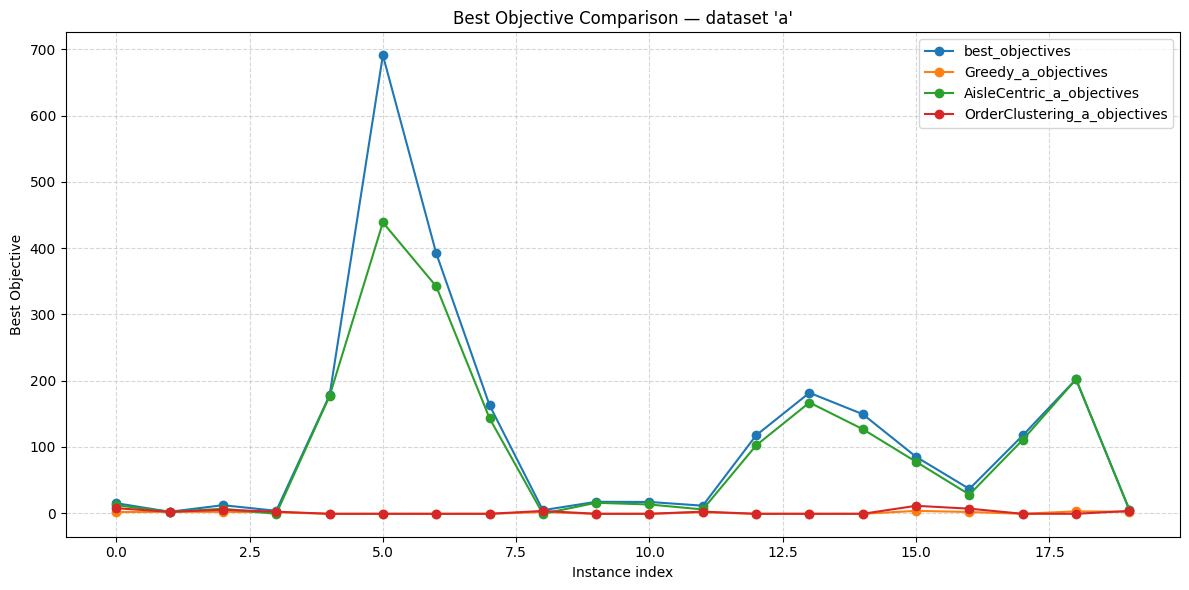

In [4]:
import argparse
import os

import matplotlib.pyplot as plt
import pandas as pd


def plot_best_objectives(csv_paths: list[str], dataset: str) -> None:
    """Plot the best_objective column from multiple CSV files as separate lines.

    Each CSV is filtered by the given dataset name. The resulting
    best_objective values are plotted as a line, using the file name
    (without extension) as the legend label.
    """
    
    plt.figure(figsize=(12, 6))

    for path in csv_paths:
        df = pd.read_csv(path)
        df_filtered = df[df["dataset"] == dataset].reset_index(drop=True)

        if df_filtered.empty:
            print(f"Warning: no rows with dataset='{dataset}' in {path}, skipping.")
            continue

        label = os.path.splitext(os.path.basename(path))[0]
        plt.plot(df_filtered["best_objective"].values, marker="o", label=label)

    plt.title(f"Best Objective Comparison — dataset '{dataset}'")
    plt.xlabel("Instance index")
    plt.ylabel("Best Objective")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    parser = argparse.ArgumentParser(
        description="Compare best_objective values across multiple CSV files."
    )

    # parser.add_argument(
    #     "csv_files",
    #     nargs="+",
    #     help="Paths to CSV files (must contain 'dataset' and 'best_objective' columns).",
    # )

    # parser.add_argument(
    #     "--dataset",
    #     required=True,
    #     help="Dataset name to filter rows by.",
    # )

    csv_files = [
        "../objectives/best_objectives.csv",
        "../objectives/Greedy_a_objectives.csv",
        "../objectives/AisleCentric_a_objectives.csv",
        "../objectives/OrderClustering_a_objectives.csv",
    ]

    dataset = 'a'

    # args = parser.parse_args()
    plot_best_objectives(csv_files, dataset)
